In [16]:
from google.colab import drive
import os

# Mount Google Drive nếu chưa mount
if not os.path.exists("/content/drive"):
    drive.mount('/content/drive')

# Giải nén file zip từ Drive vào ổ SSD tạm thời của Colab (/content/dataset)
# Giúp tăng tốc độ đọc dữ liệu lên gấp 10-20 lần!
!unzip -q "/content/drive/MyDrive/archive.zip" -d "/content/dataset"

print("Giải nén thành công! Kiểm tra thư mục:")
!ls /content/dataset

unzip:  cannot find or open /content/drive/MyDrive/archive.zip, /content/drive/MyDrive/archive.zip.zip or /content/drive/MyDrive/archive.zip.ZIP.
Giải nén thành công! Kiểm tra thư mục:
ls: cannot access '/content/dataset': No such file or directory


Found 3458 images belonging to 5 classes.
Found 860 images belonging to 5 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_49 (Conv2D)              │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_49 (MaxPooling2D) │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732,421 (6.61 MB)

 Trainable params: 1,732,421 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 36s 294ms/step - accuracy: 0.3921 - loss: 1.3556 - val_accuracy: 0.4837 - val_loss: 1.2040
Epoch 2/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 34s 306ms/step - accuracy: 0.4942 - loss: 1.1802 - val_accuracy: 0.5314 - val_loss: 1.1168
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 29s 260ms/step - accuracy: 0.5697 - loss: 1.0642 - val_accuracy: 0.6360 - val_loss: 0.9518
Epoch 4/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 34s 316ms/step - accuracy: 0.5977 - loss: 1.0177 - val_accuracy: 0.6209 - val_loss: 0.9449
Epoch 5/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 30s 272ms/step - accuracy: 0.6243 - loss: 0.9431 - val_accuracy: 0.6163 - val_loss: 0.9800
Epoch 6/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 33s 307ms/step - accuracy: 0.6319 - loss: 0.9237 - val_accuracy: 0.6384 - val_loss: 0.8916
Epoch 7/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 29s 263ms/step - accuracy: 0.6423 - loss: 0.9165 - val_accuracy: 0.6570 - val_loss: 0.8589
Epoch 8/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 29s 263ms/step - accuracy: 0.6631 - loss: 0

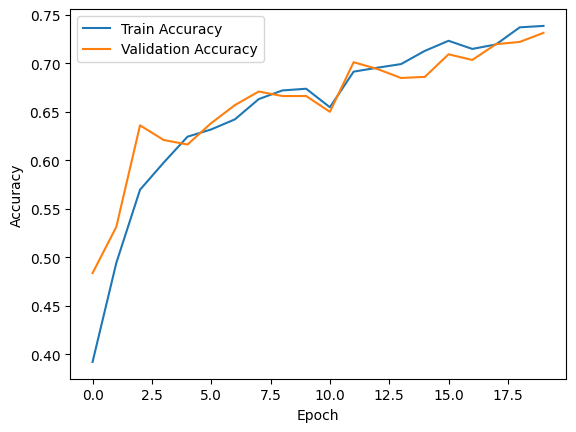

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Đường dẫn dataset hoa
train_dir = "/content/drive/MyDrive/archive"

img_width, img_height = 100, 100
batch_size = 32

# Tăng cường dữ liệu
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

# Tập train
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Tập validation
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Số loại hoa
num_classes = len(train_generator.class_indices)

# Mô hình CNN
model = Sequential([
    Conv2D(32, (3,3), activation='relu',
           input_shape=(img_width, img_height, 3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

# Sử dụng Adam thay cho RMSprop
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Huấn luyện
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)

# Vẽ biểu đồ Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


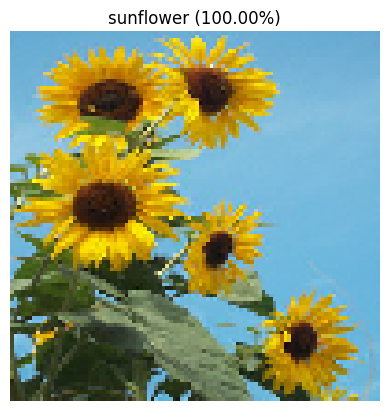

Loài hoa: sunflower
Độ tin cậy: 100.00%


In [50]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_path = "/content/drive/MyDrive/archive/sunflower/14121915990_4b76718077_m.jpg"

img = image.load_img(img_path, target_size=(100,100))
img_array = image.img_to_array(img) / 255.0
img_input = np.expand_dims(img_array, axis=0)

pred = model.predict(img_input)

class_names = list(train_generator.class_indices.keys())


predicted_class = np.argmax(pred)
predicted_name = class_names[predicted_class]
confidence = np.max(pred) * 100

plt.imshow(img)
plt.axis("off")
plt.title(f"{predicted_name} ({confidence:.2f}%)")
plt.show()

print("Loài hoa:", predicted_name)
print(f"Độ tin cậy: {confidence:.2f}%")